In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

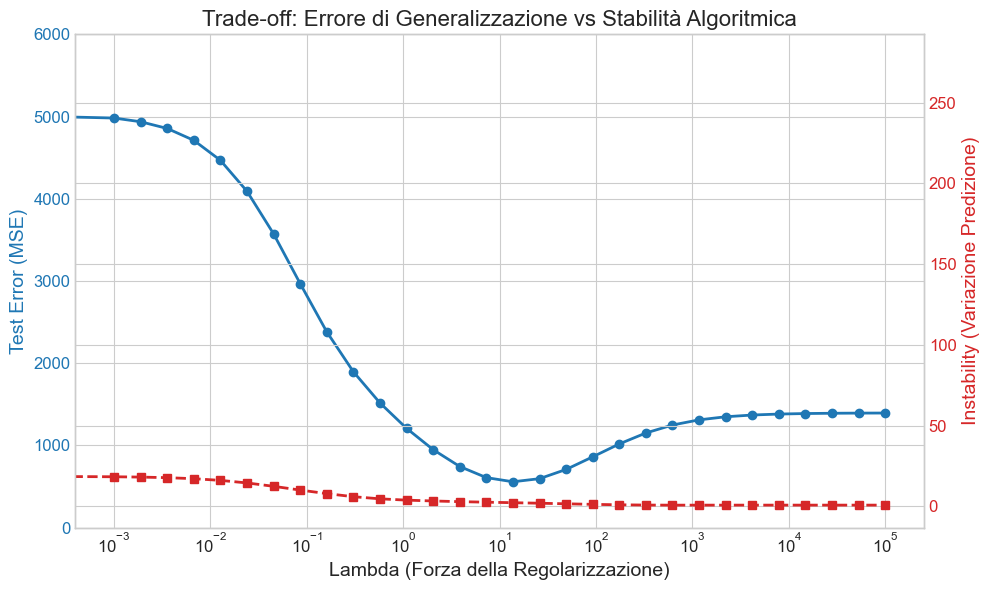

In [ ]:
df_base = pd.read_csv('results/results_synthetic.csv')

fig, ax1 = plt.subplots()

ax1.set_xscale('log')
ax1.set_xlabel('Lambda (Forza della Regolarizzazione)')

color_error = 'tab:blue'
ax1.set_ylabel('Test Error (MSE)', color=color_error)
ax1.set_ylim(0, 6000)
ax1.plot(df_base['lambda'], df_base['test_error'], marker='o', linewidth=2, color=color_error, label='Test Error')
ax1.tick_params(axis='y', labelcolor=color_error)

ax2 = ax1.twinx()
color_instab = 'tab:red'
ax2.set_ylabel('Instability (Variazione Predizione)', color=color_instab)
ax2.plot(df_base['lambda'], df_base['instability'], marker='s', linestyle='--', linewidth=2, color=color_instab, label='Instability')
ax2.tick_params(axis='y', labelcolor=color_instab)

plt.title('Trade-off: Errore di Generalizzazione vs Stabilità Algoritmica')
fig.tight_layout()
plt.show()

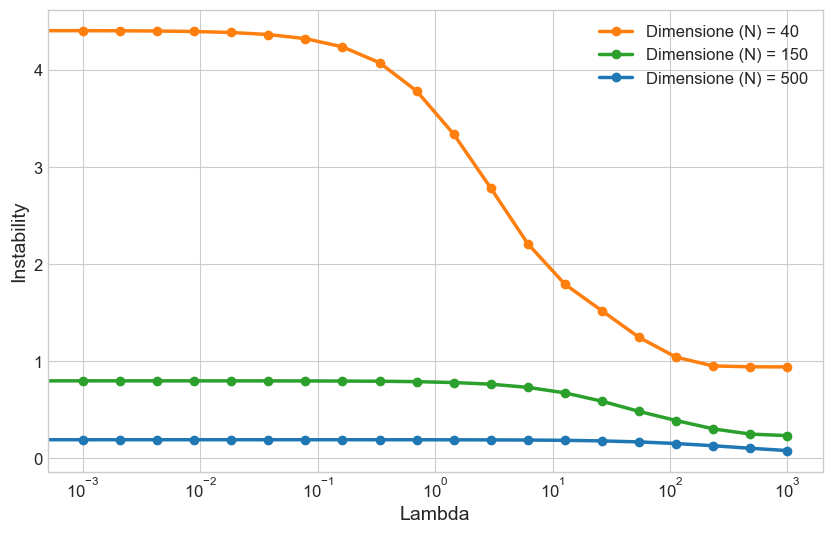

In [ ]:
df_size = pd.read_csv('results/results_dataset_size.csv')
sizes = df_size['N'].unique()

plt.figure()
colors = ['tab:orange', 'tab:green', 'tab:blue']

for i, N in enumerate(sizes):
    df_subset = df_size[df_size['N'] == N]
    plt.plot(df_subset['lambda'], df_subset['instability'], 
             marker='o', linewidth=2.5, label=f'Dimensione (N) = {int(N)}', color=colors[i])

plt.xscale('log')
plt.xlabel('Lambda')
plt.ylabel('Instability')
plt.legend()
plt.show()

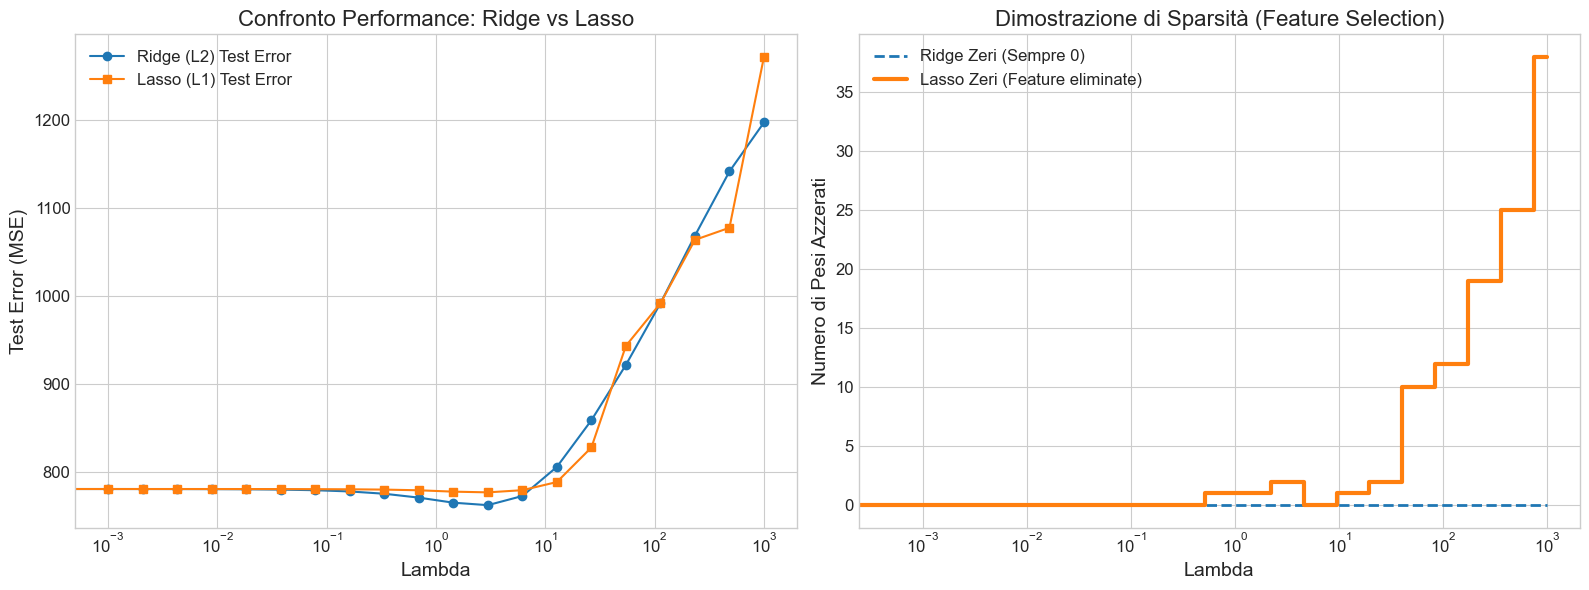

In [ ]:
df_l1l2 = pd.read_csv('results/results_l1_vs_l2.csv')

fig, (ax_err, ax_zeros) = plt.subplots(1, 2, figsize=(16, 6))

ax_err.set_xscale('log')
ax_err.plot(df_l1l2['lambda'], df_l1l2['ridge_test_error'], marker='o', label='Ridge (L2) Test Error')
ax_err.plot(df_l1l2['lambda'], df_l1l2['lasso_test_error'], marker='s', label='Lasso (L1) Test Error')
ax_err.set_xlabel('Lambda')
ax_err.set_ylabel('Test Error (MSE)')
ax_err.set_title('Confronto Performance: Ridge vs Lasso')
ax_err.legend()

ax_zeros.set_xscale('log')
ax_zeros.plot(df_l1l2['lambda'], df_l1l2['ridge_zeros'], linestyle='--', color='tab:blue', label='Ridge Zeri (Sempre 0)', linewidth=2)
ax_zeros.step(df_l1l2['lambda'], df_l1l2['lasso_zeros'], where='mid', color='tab:orange', label='Lasso Zeri (Feature eliminate)', linewidth=3)

ax_zeros.set_xlabel('Lambda')
ax_zeros.set_ylabel('Numero di Pesi Azzerati')
ax_zeros.set_title('Dimostrazione di Sparsità (Feature Selection)')
ax_zeros.legend()

plt.tight_layout()
plt.show()